In [48]:
from liset_seizures import liset_seizures
import os
import matplotlib.pyplot as plt
import numpy as np
from liset_tk.signal_aid import bandpass_filter

In [128]:
# parent=r"E:\neurospark_mat\KA MODEL TRANSITION SESSIONS"
parent=r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\KA MODEL TRANSITION SESSIONS"
sessions=os.listdir(parent) 

for i,s in enumerate(sessions):
    print(f"{i}: {s}")

idx = int(input("Select session index: "))
session = sessions[idx]
data_path=os.path.join(parent,session)
print(f"Selected: {idx}: {session}")

0: Calb01uLED_hippo_2022-12-21_13-10-56_1558um
1: Calb01uLED_hippo_2022-12-21_14-12-20_1558um
2: Calb01uLED_hippo_2022-12-21_17-39-06_1558um
3: Calb01uLED_hippo_2022-12-22_09-52-13_1558um
4: Calb01uLED_hippo_2023-01-09_11-28-01_1558um
5: Calb01uLED_hippo_2023-01-12_10-19-17_1558um
6: Calb01uLED_hippo_2023-01-13_09-56-47_1558um
7: KA MODEL SESSIONS.xlsx
8: Thy01uLED_hippo_2022-12-21_merged
9: Thy01uLED_hippo_2022-12-22_merged
10: Thy01uLED_hippo_2023-01-09_12-45-53_1558um
11: Thy01uLED_hippo_2023-01-17_09-36-28_1558um
12: Thy01uLED_hippo_2023-01-17_merged
Selected: 0: Calb01uLED_hippo_2022-12-21_13-10-56_1558um


In [129]:
liset=liset_seizures(data_path,shank=3,downsample=1000,normalize=True,start=0,verbose=True)

.mat file loaded with h5py
Channels loaded: [16.  4.  1. 13. 15.  3.  2. 14.]
Number of channels: 43
Data loaded from C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\KA MODEL TRANSITION SESSIONS\Calb01uLED_hippo_2022-12-21_13-10-56_1558um/lfp.dat
Data shape: (110290944, 8)
Data type: float64
Downsampling data from 30000 Hz to 1000 Hz... Done!
Normalizing data... Done!
Shape of loaded data after downsampling and z-score:  (3676365, 8)
IISs times loaded: [1156296 1347305 1384669 1384698 2663543 2663762 2663807 2663852 2663885
 2663912 2664032 2664291 2664616 2664629 2664666 2664704 2664720 2664730
 2664742 2664765 2664804 2664982 2664994 2665026 2665067 2665078 2665089
 2665101 2665113 3283095 3284185 3285035 3285592 3285947 3286783 3287253
 3287972 3288099 3288438 3288931 3289258 3289959 3290367 3290879 3290995
 3291026 3291458 3291487 3291825 3291893 3291922 3292229 3292380 3292722
 3293001 3293150 3293166 3293483 3293524 3293646 3293670 3293687 3293716
 3293727 3293790 3293846 3293861 

In [130]:
liset.seizure_times

array([[2660000, 2665000],
       [3285000, 3315000]])

In [131]:
liset.IISs_times
print(liset.IISs_times)
print(liset.IISs_times[:20] / liset.fs)  # in seconds

[1156296 1347305 1384669 1384698 2663543 2663762 2663807 2663852 2663885
 2663912 2664032 2664291 2664616 2664629 2664666 2664704 2664720 2664730
 2664742 2664765 2664804 2664982 2664994 2665026 2665067 2665078 2665089
 2665101 2665113 3283095 3284185 3285035 3285592 3285947 3286783 3287253
 3287972 3288099 3288438 3288931 3289258 3289959 3290367 3290879 3290995
 3291026 3291458 3291487 3291825 3291893 3291922 3292229 3292380 3292722
 3293001 3293150 3293166 3293483 3293524 3293646 3293670 3293687 3293716
 3293727 3293790 3293846 3293861 3293916 3294019 3294038 3294050 3294183
 3294243 3294308 3294337 3294359 3294403 3294432 3294471 3294548 3294587
 3294626 3294653 3294699 3294735 3294841 3294877 3294939 3294994 3295031
 3295089 3295116 3295155 3295186 3295246 3295281 3295313 3295372 3295409
 3295450 3295487 3295514 3295537 3295571 3295594 3295640 3295708 3295753
 3295779 3295808 3295886 3295964 3295989 3296039 3296091 3296146 3296221
 3296252 3296309 3296349 3296411 3296542 3296604 32

Selected channel: 0
[-0.1301  -0.10175  0.04034  0.09143  0.1312 ]
[]


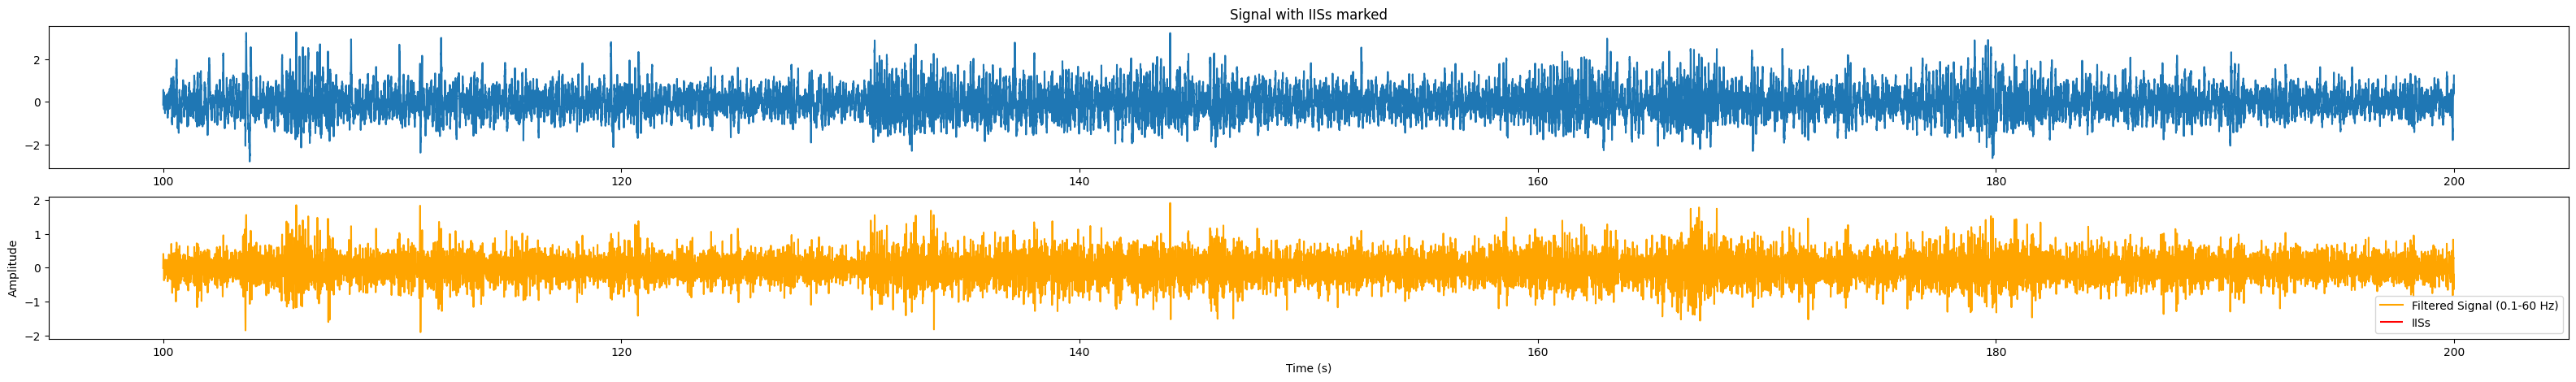

Selected channel: 1
[-0.1892   -0.1328   -0.004818 -0.097    -0.02531 ]
[]


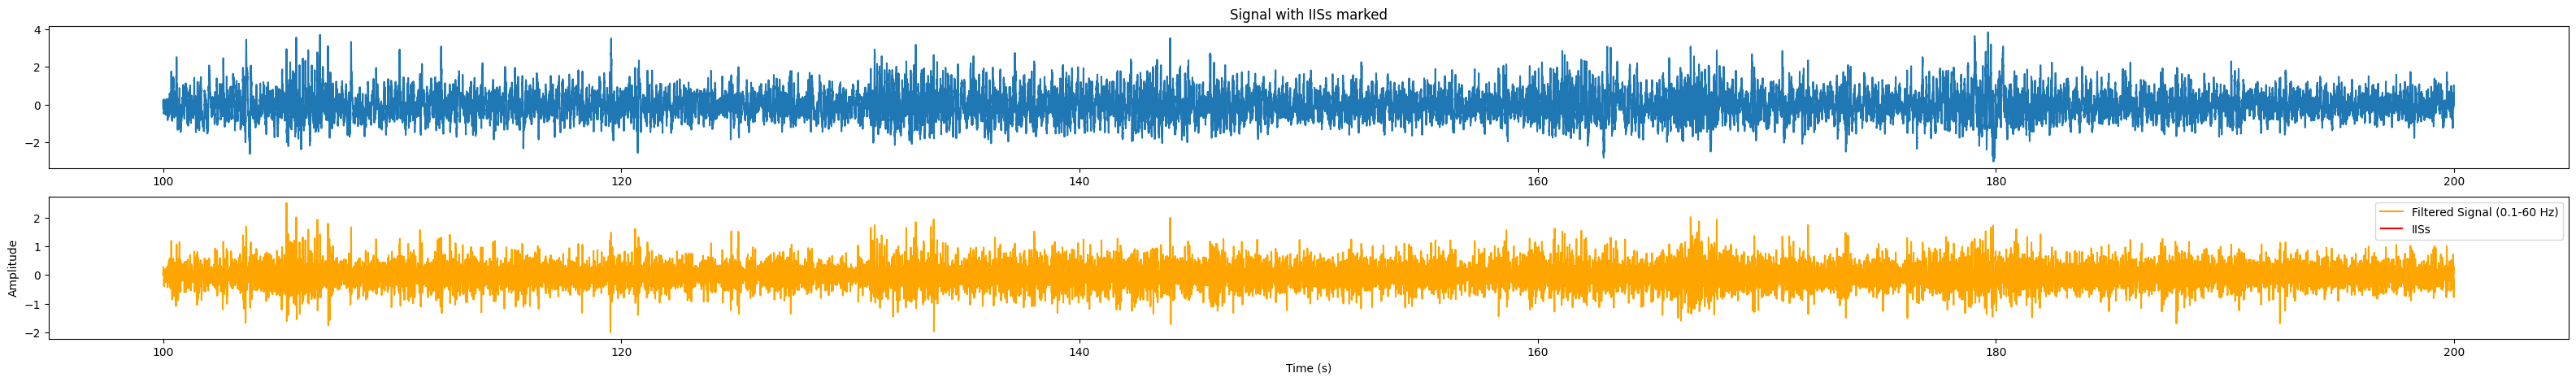

Selected channel: 2
[-0.2795  -0.2052  -0.0909  -0.0909   0.02351]
[]


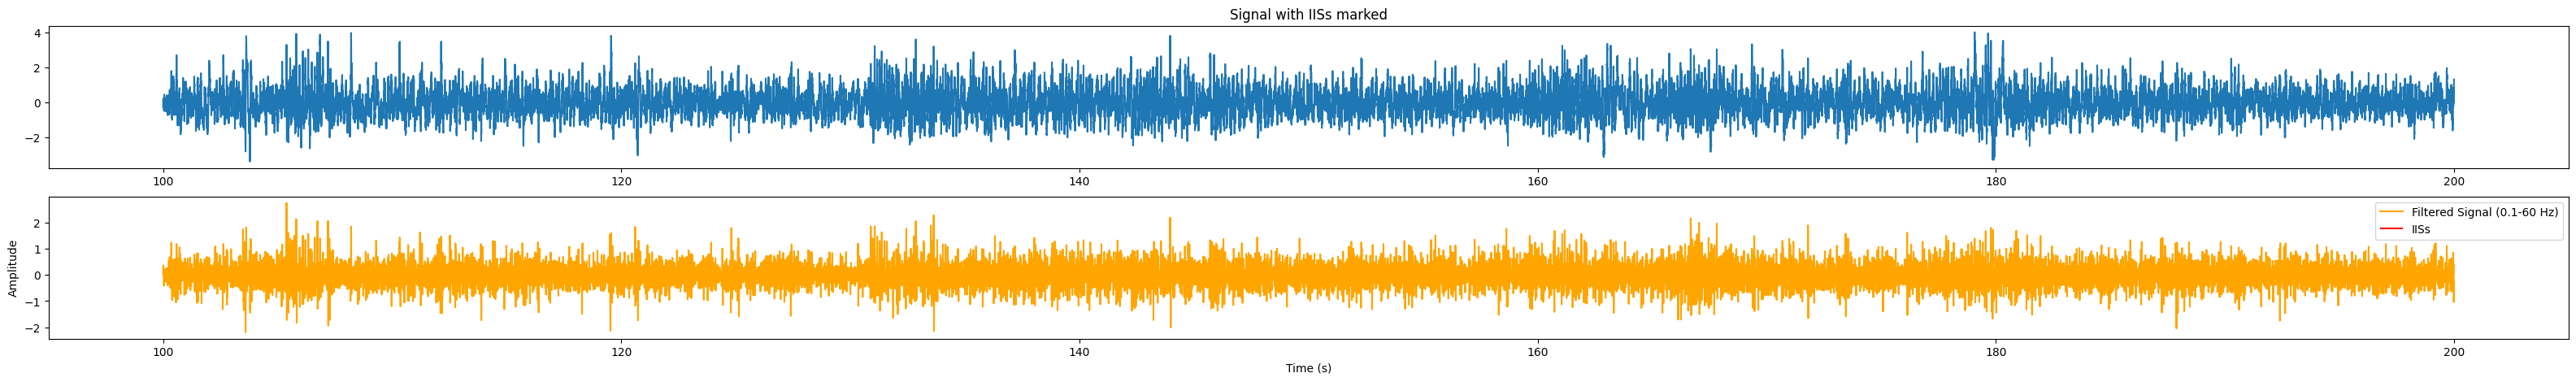

Selected channel: 3
[0.3667 0.4897 0.531  0.5923 0.674 ]
[]


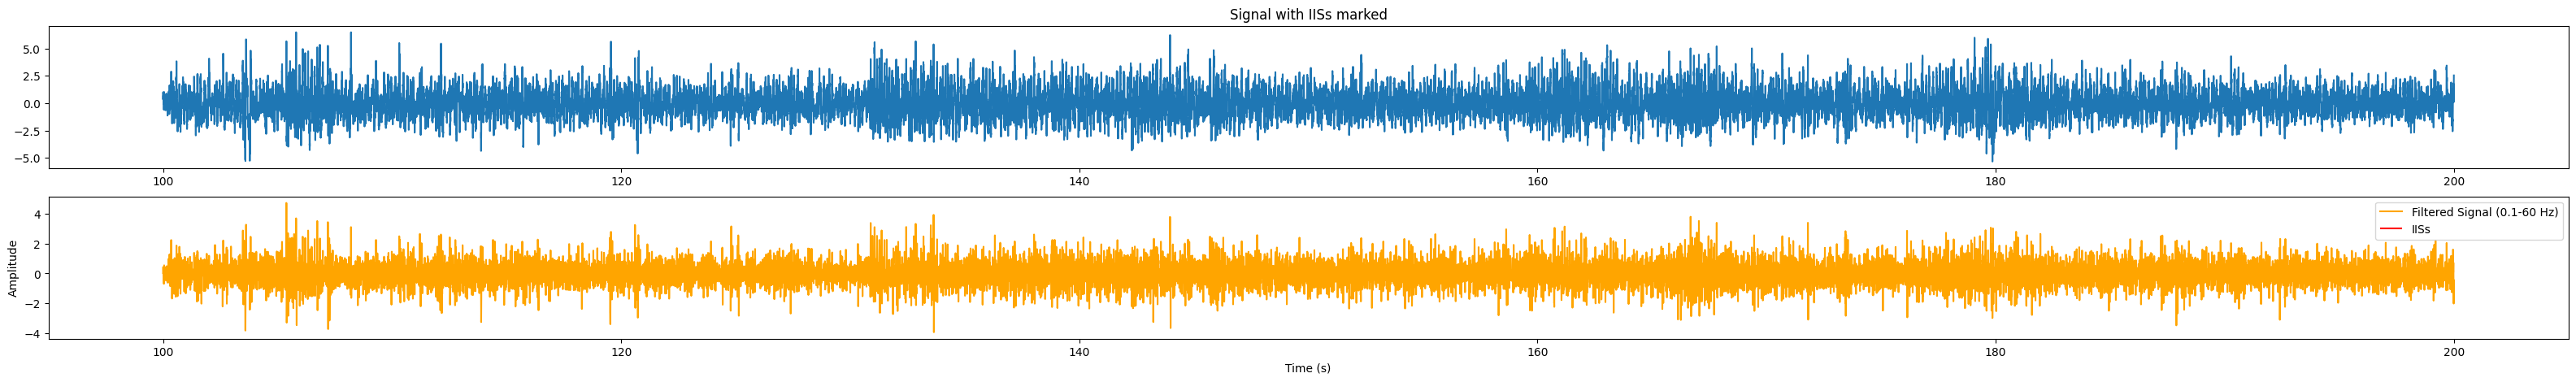

Selected channel: 4
[0.2208 0.2917 0.4573 0.575  0.705 ]
[]


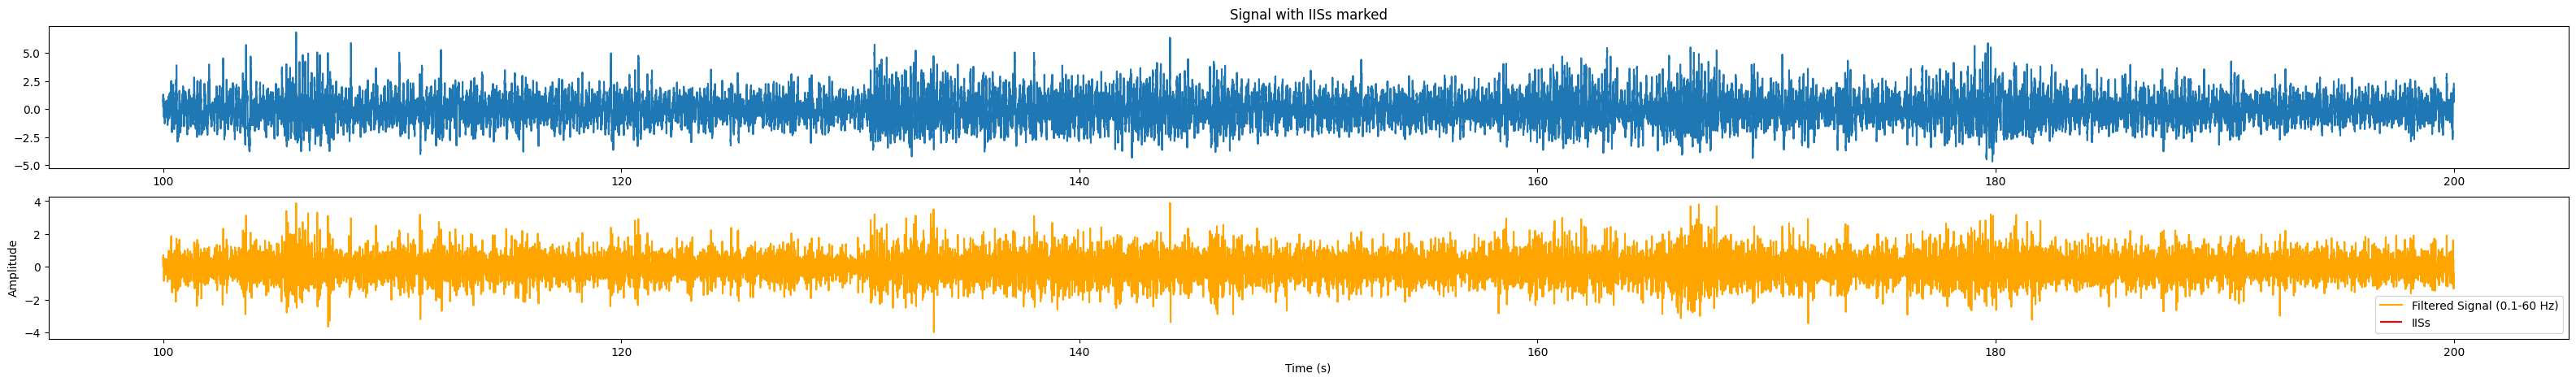

Selected channel: 5
[-0.2054  -0.1553  -0.12024 -0.09515  0.10046]
[]


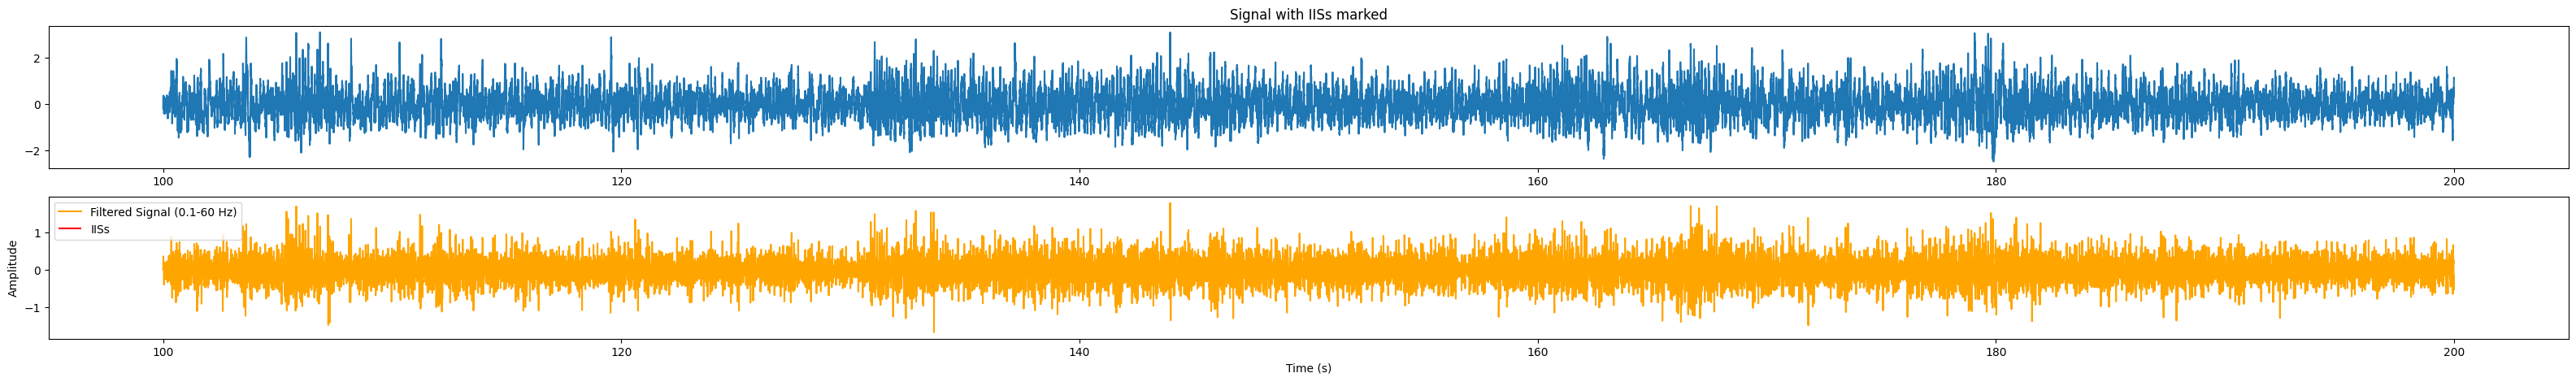

Selected channel: 6
[-0.0389   0.1477   0.1329   0.11334  0.1771 ]
[]


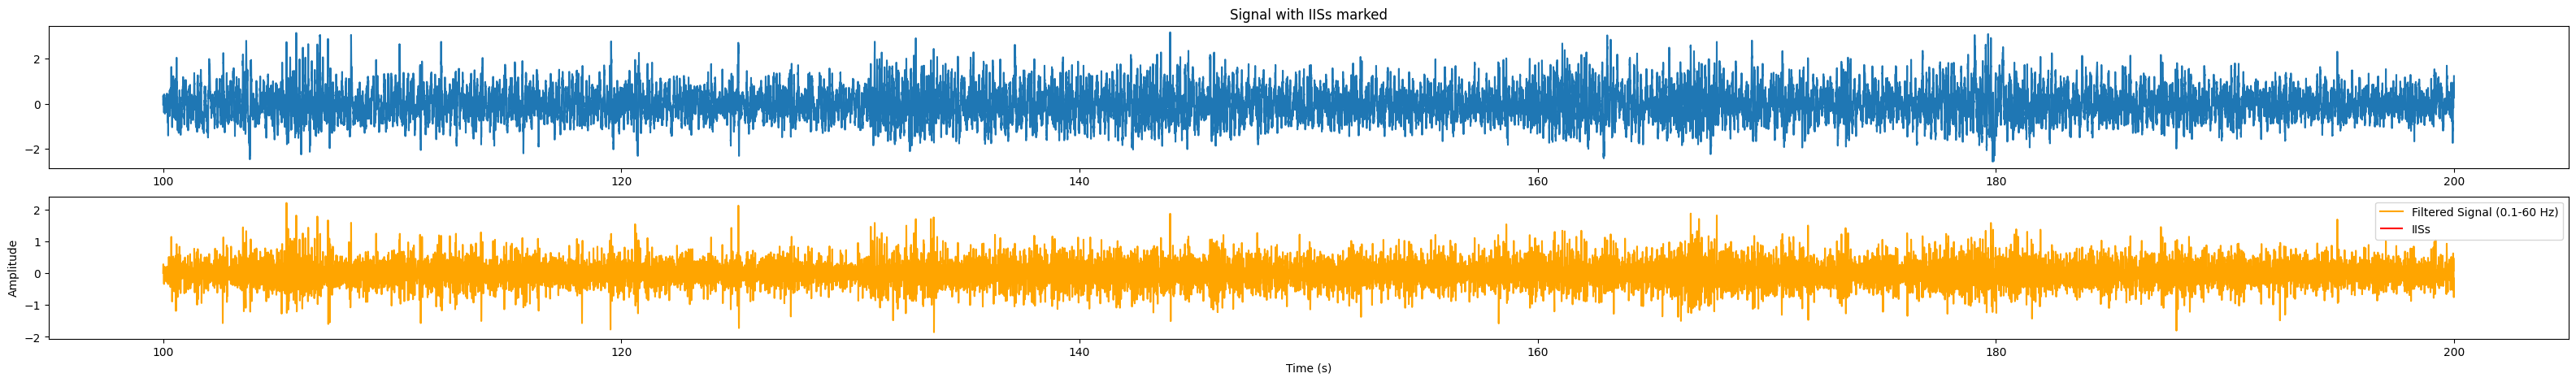

Selected channel: 7
[0.2979 0.5283 0.6084 0.518  0.798 ]
[]


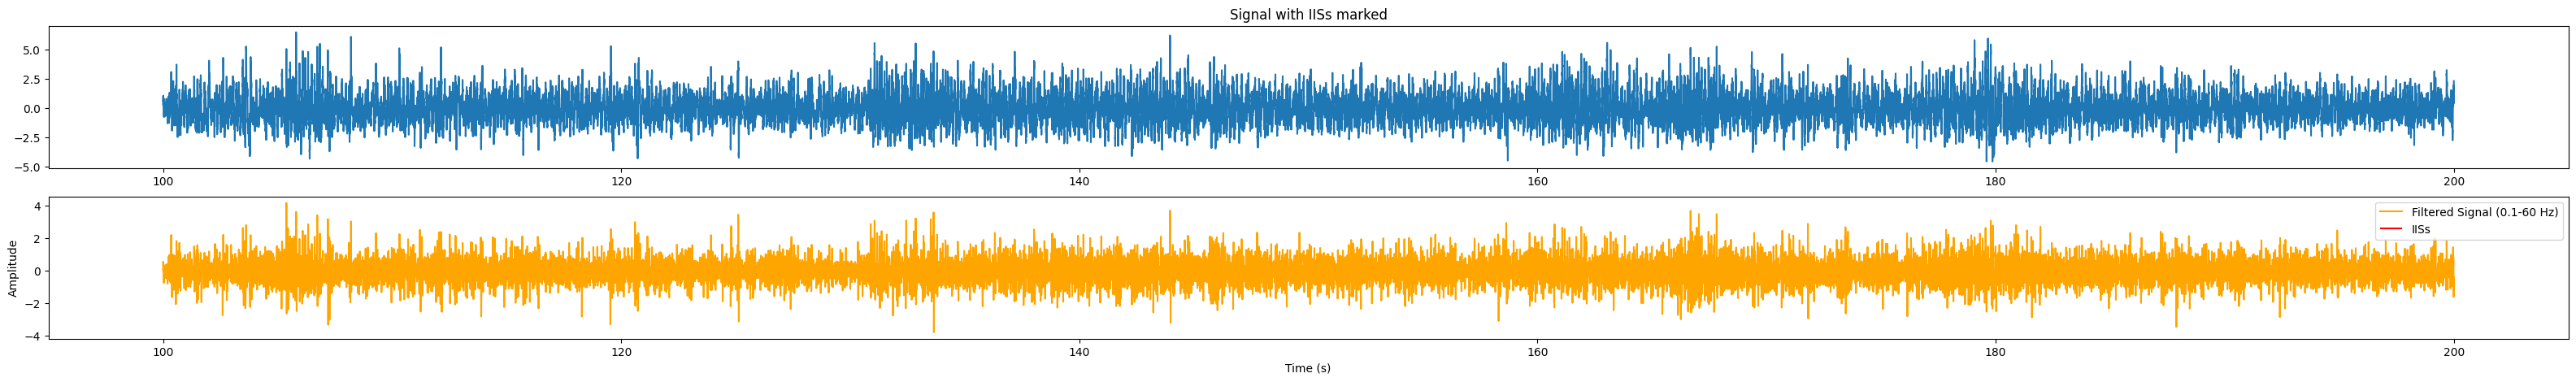

In [132]:
window = [100,200]  # seconds
data = liset.data[window[0]*liset.fs : window[1]*liset.fs, :]
channel_list=[0,1,2,3,4,5,6,7]
for channel in channel_list:
    print(f"Selected channel: {channel}")
    data_channel=data[:,channel]
    # print(f"Data shape in window {window}: {data.shape}")
    filtered=bandpass_filter(data_channel,[10,70], liset.fs,)
    print(data[:5,channel])
    time = np.arange(data.shape[0]) / liset.fs + window[0]  # shift to window start
    min_val, max_val = np.min(data_channel), np.max(data_channel)
    fig, axes = plt.subplots(2,1, figsize=(40, 5))
    axes[0].plot(time,data_channel, label="Signal")
    axes[1].plot(time, filtered, label="Filtered Signal (0.1-60 Hz)", color='orange')
    # Plot IISs inside window
    if hasattr(liset, "IISs_times"):
        # Convert sample indices to seconds
        IIS_times_sec = liset.IISs_times / liset.fs

        # Keep only IISs that fall inside window
        mask = (IIS_times_sec >= window[0]) & (IIS_times_sec <= window[1])
        IIS_in_window = IIS_times_sec[mask]

        # Mark them on the plot
        # plt.scatter(IIS_in_window, 
        #             np.zeros_like(IIS_in_window),  # baseline marker
        #             color="red", marker="x", s=100, label="IISs")
        for ax in axes:
            ax.vlines(IIS_in_window, ymin=min(data_channel), ymax=max(data_channel), color="red", label="IISs")
        print(IIS_in_window)

    if hasattr(liset, "seizure_times"):
        # Convert sample indices to seconds
        seizure_times_sec = liset.seizure_times / liset.fs
        i=0
        # Keep only seizures that fall inside window
        for start, end in seizure_times_sec:
                    if end >= window[0] and start <= window[1]:
                        start = max(start, window[0])
                        end = min(end, window[1])
                        for ax in axes:
                            fill_SZ = ax.fill_between([start, end],
                                                min_val, max_val,
                                                color="tab:purple", alpha=0.3,
                                                label="Seizure" if i==0 else None)
                            i+=1

        # Mark them on the plot
        # plt.vlines(seizures_in_window, ymin=min(data[:,0]), ymax=max(data[:,0]), color="green", label="Seizures")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    axes[0].set_title("Signal with IISs marked")
    plt.show()


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Event samples [100000, 200000]'}, xlabel='Time (s)', ylabel='Amplitude (mV)'>)

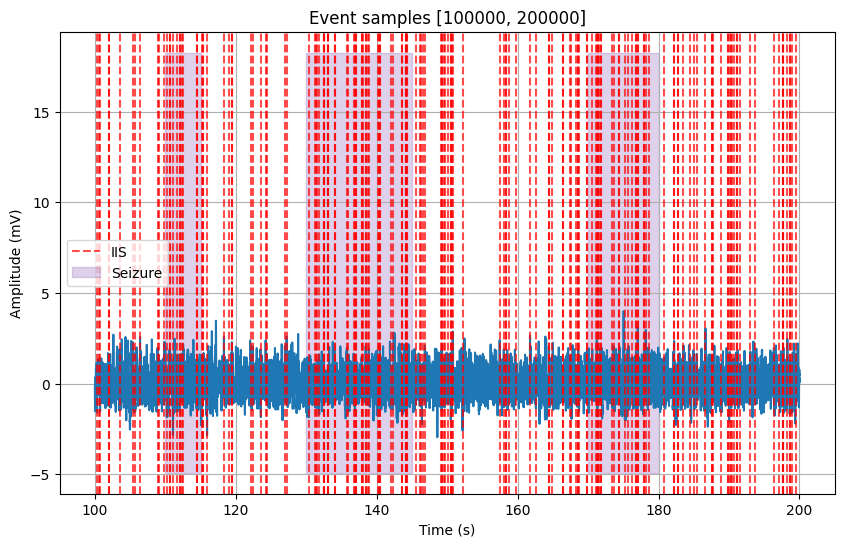

In [120]:
liset.plot_event_with_IISs_and_seizures(
        event=window,             # [start, end] in samples
        offset=1.5,
        extend=0,
        delimiter=False,
        show=True,
        filtered=[1,60],
        title='',
        ch=[0,],  # channels to plot, None for all
        ylim=False,
        line_color=False,
        show_IISs=True,
        show_seizures=True,
    )

In [121]:
ISIs = np.diff(liset.IISs_times) / liset.fs  # in seconds
average_isi = np.mean(ISIs)
print(f"Average IISs rate: {1/average_isi} Hz, Average IS")
print(f"Mean ISI: {np.mean(ISIs):.3f} s")
print(f"Median ISI: {np.median(ISIs):.3f} s")
print(f"Std ISI: {np.std(ISIs):.3f} s")
print(f"Number of intervals: {len(ISIs)}")


Average IISs rate: 1.1043438818296665 Hz, Average IS
Mean ISI: 0.906 s
Median ISI: 0.456 s
Std ISI: 1.353 s
Number of intervals: 3988


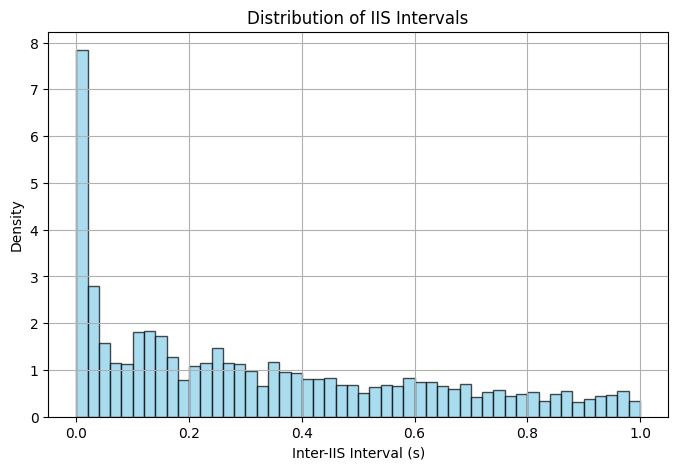

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(ISIs, bins=50, density=True, alpha=0.7, color="skyblue", edgecolor="k", range=(0,1))
plt.xlabel("Inter-IIS Interval (s)")
plt.ylabel("Density")
plt.title("Distribution of IIS Intervals")
plt.grid(True)
plt.show()
